In [ ]:
#%pip install pandas numpy seaborn matplotlib
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 185.7 kB/s  0:00:54m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 186.7 kB/s  0:00:27 eta 0:00:02
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 176.5 kB/s  0:00:47m0:00:0100:02
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 188.8 kB/s  0:00:14 eta 0:00:02
Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 184.1 kB/s  0:00:26 eta 0:00:01
   ━━━━━━━━━━━━━

In [6]:
# Read csv
df = pd.read_csv('../data/processed/candor_dataset_clean.csv')
print(df)

                                   call_id                  actor_id  \
0     dd9b5c4a-19cb-4af3-b0e8-f1ce12c5b8fe  5f582002dff3f038d1eb83c4   
1     dd9b5c4a-19cb-4af3-b0e8-f1ce12c5b8fe  5e97478f8b670f09dad1fd02   
2     dbe27cbe-5693-4994-b281-d481a5a4e1f0  5f5ce7f940a2614f6cb6e747   
3     dbe27cbe-5693-4994-b281-d481a5a4e1f0  5f4bc3259e842579bf1a8b0a   
4     3edbfb87-6b83-4dd0-a4d8-09ca1eba6a3e  5de855017d44177cafe19840   
...                                    ...                       ...   
3197  473435df-b97f-4c9f-a8e2-8e3fc66a8902  57d6dd8d6598aa000199188b   
3198  8287d05f-f9d4-46d8-bb41-6a2e7b46987b  5f7e700fa9c86614bbb5343a   
3199  8287d05f-f9d4-46d8-bb41-6a2e7b46987b  5ea74ea1fb3f711081d6763c   
3200  262878c2-d717-48ac-a35a-73e91bc685a6  5e820a4e26ed71918013d860   
3201  262878c2-d717-48ac-a35a-73e91bc685a6  5f112c3557b476490891ec16   

                    partner_id  speech_activity_actor  \
0     5e97478f8b670f09dad1fd02                  0.453   
1     5f582002dff3f03

      speech_activity_actor  speech_activity_partner  how_enjoyable_actor  \
0                     0.453                    0.360                  6.0   
1                     0.416                    0.399                  5.0   
2                     0.373                    0.414                  5.0   
3                     0.428                    0.344                  9.0   
4                     0.264                    0.510                  9.0   
...                     ...                      ...                  ...   
1596                  0.528                    0.214                  5.0   
1597                  0.465                    0.384                  7.0   
1598                  0.433                    0.484                  9.0   
1599                  0.222                    0.452                  8.0   
1600                  0.517                    0.253                  8.0   

      how_enjoyable_partner  speech_activity_ave  speech_activity_diff  \
0

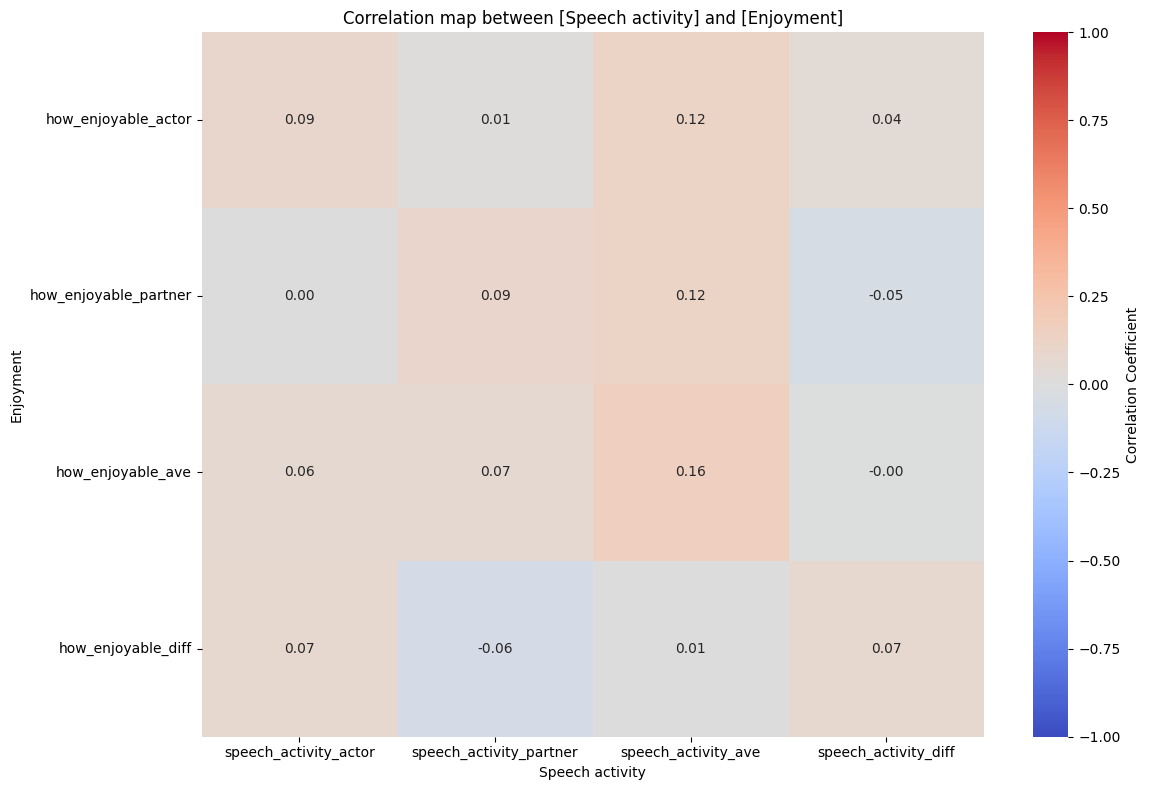

In [7]:
# Make a pair dataset by deleting the lines with the same call_id
df_pair = df.drop_duplicates(subset=['call_id'])
df_pair = df_pair.reset_index(drop=True)

# Extract necessary parameters:
df_subset = df_pair.filter(
  items=['speech_activity_actor', 'speech_activity_partner', 'how_enjoyable_actor', 'how_enjoyable_partner']
  )

# Add other columns
df_subset['speech_activity_ave'] = (df_subset['speech_activity_actor'] + df_subset['speech_activity_partner'])/2
df_subset['speech_activity_diff'] = df_subset['speech_activity_actor'] - df_subset['speech_activity_partner']
df_subset['speech_activity_abs'] = abs(df_subset['speech_activity_diff'])

df_subset['how_enjoyable_ave'] = (df_subset['how_enjoyable_actor'] + df_subset['how_enjoyable_partner'])/2
df_subset['how_enjoyable_diff'] = df_subset['how_enjoyable_actor'] - df_subset['how_enjoyable_partner']
df_subset['how_enjoyable_abs'] = abs(df_subset['how_enjoyable_diff'])

print(df_subset)

# Make a 4×4 correlation map
src_cols = ['speech_activity_actor', 'speech_activity_partner', 'speech_activity_ave', 'speech_activity_diff']
tar_cols = ['how_enjoyable_actor', 'how_enjoyable_partner', 'how_enjoyable_ave', 'how_enjoyable_diff']
corr_subset = df_subset.corr().loc[tar_cols, src_cols]
print(corr_subset)

plt.figure(figsize=(12,8))
sns.heatmap(
  corr_subset,
  annot=True,
  cmap='coolwarm',
  fmt=".2f",
  vmin=-1, vmax=1,
  center=0,
  cbar_kws={"label": "Correlation Coefficient"}
)

plt.title("Correlation map between [Speech activity] and [Enjoyment]")
plt.xlabel("Speech activity")
plt.ylabel("Enjoyment")

plt.tight_layout()
plt.show()

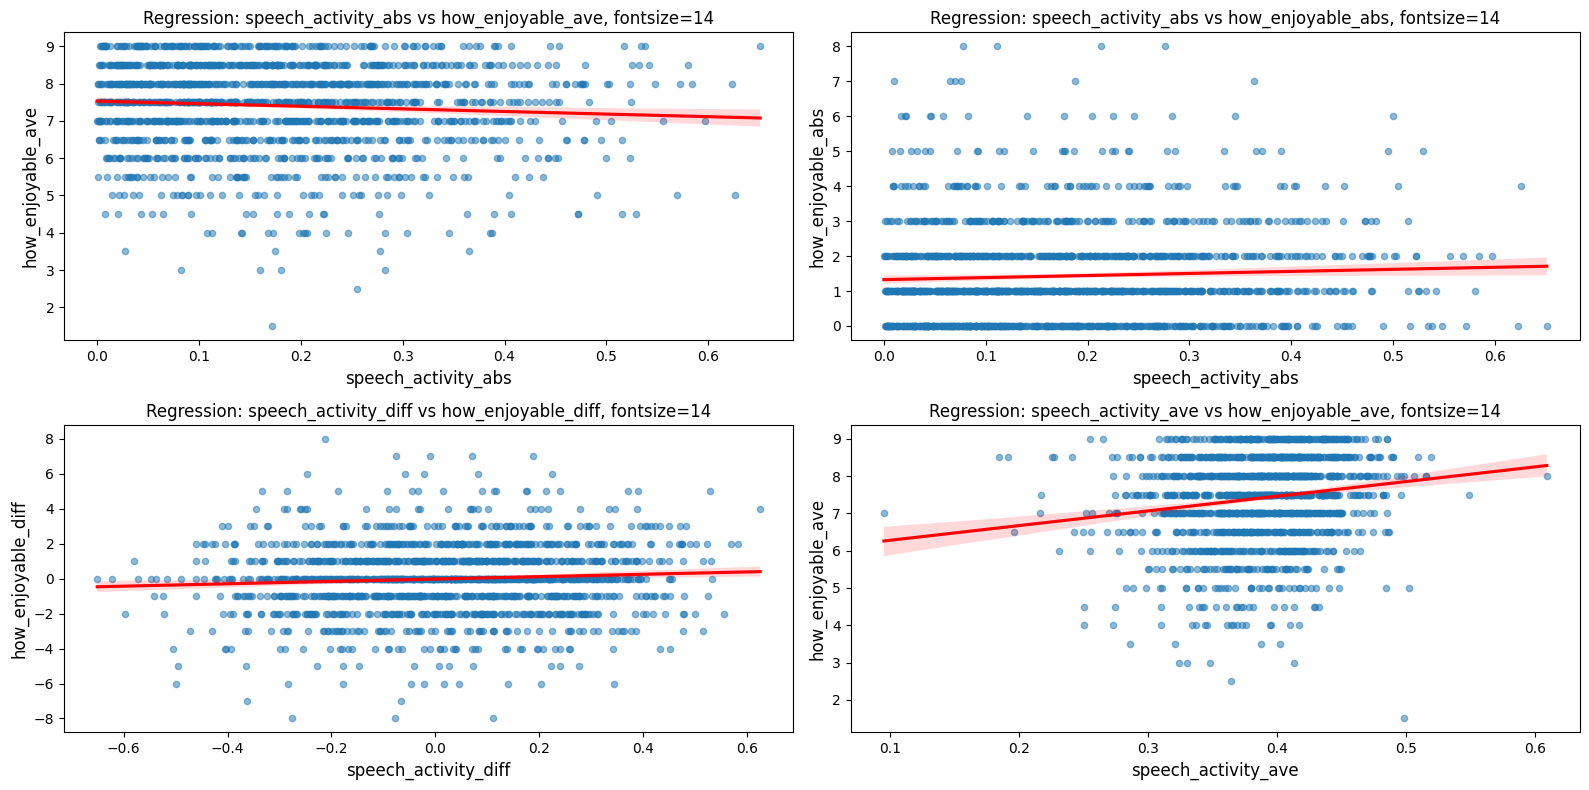

In [8]:
# Make four regressions
# H3-1 : lower activity abs -> higher enjoyable ave
# H3-2 : lower activity abs -> lower enjoyable abs
# H3-3 : higher activity diff -> higher enjoyable diff
# H3-4 : higher activity ave -> higher enjoyable ave

pairs = [('speech_activity_abs', 'how_enjoyable_ave'),
          ('speech_activity_abs', 'how_enjoyable_abs'), 
          ('speech_activity_diff', 'how_enjoyable_diff'), 
          ('speech_activity_ave', 'how_enjoyable_ave')]

fig, axes = plt.subplots(2, 2, figsize=(16,8))
axes = axes.flatten()

for i, (col_x, col_y) in enumerate(pairs):
  sns.regplot(
    data=df_subset,
    x=col_x,
    y=col_y,
    ax=axes[i],
    scatter_kws={'alpha': 0.5, 's': 20},
    line_kws={'color': 'red'},
    ci=95
  )

  axes[i].set_title(f"Regression: {col_x} vs {col_y}, fontsize=14")
  axes[i].set_xlabel(col_x, fontsize=12)
  axes[i].set_ylabel(col_y, fontsize=12)

plt.tight_layout()
plt.show()